In [ ]:
# Importo le librerie
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Carico il dataset
from google.colab import files
uploaded = files.upload()

# Leggo il file CSV caricato
nome_file = list(uploaded.keys())[0]
df = pd.read_csv(nome_file)

print("Il dataset utilizzato è stato scaricato da Investing.com.")
print("Esso non è stato modificato prima di essere caricato. Contiene la prima colonna con le date dal 3 nvombre 2020 fino al 31 ottobre 2025 ")
print("La colonna Ultimo rappresenta il prezzo di chiusura della giornata.")
print("Minimo e Massimo rappresentano il prezzo minimo e massimo che il titolo ha raggiunto nella giornata di contrattazione.")
print("Apertura è il primo prezzo a cui un’azione viene scambiata quando il mercato apre.")
print("Var. % è la variazione percentuale rispetto al giorno precedente e rappresenta il rendimento giornaliero.")
print("Vol. indica il volume delle azioni scambiate nel giorno specifico.")

# Controllo che sia andato tutto bene
print("Prime 5 righe del dataset:")
print(df.head())
print("\nInformazioni sul DataFrame:")
df.info()

# Elimino la colonna Vol.
df.drop(columns=['Vol.'], inplace=True)

# Controllo che sia andato tutto bene
print("Prime 5 righe del dataset:")
print(df.head())
print("\nInformazioni sul DataFrame:")
df.info()

# Controllo se ci sono valori mancanti
print("Valori mancanti per colonna:")
print(df.isnull().sum())

Saving MSFT Cronologia Dati.csv to MSFT Cronologia Dati (2).csv
Il dataset utilizzato è stato scaricato da Investing.com.
Esso non è stato modificato prima di essere caricato. Contiene la prima colonna con le date dal 3 nvombre 2020 fino al 31 ottobre 2025 
La colonna Ultimo rappresenta il prezzo di chiusura della giornata.
Minimo e Massimo rappresentano il prezzo minimo e massimo che il titolo ha raggiunto nella giornata di contrattazione.
Apertura è il primo prezzo a cui un’azione viene scambiata quando il mercato apre.
Var. % è la variazione percentuale rispetto al giorno precedente e rappresenta il rendimento giornaliero.
Vol. indica il volume delle azioni scambiate nel giorno specifico.
Prime 5 righe del dataset:
         Data  Ultimo Apertura Massimo  Minimo    Vol.  Var. %
0  31.10.2025  517,81   528,88  529,32  515,10  34,01M  -1,51%
1  30.10.2025  525,76   530,48  534,97  522,12  41,02M  -2,92%
2  29.10.2025  541,55   544,94  546,27  536,73  36,02M  -0,10%
3  28.10.2025  542,0

In [ ]:
# Definisco le costanti
TRAIN_SIZE = 0.7
RANDOM_STATE = 42
LAGS = 5
MEDIA_MOBILE_WINDOWS = [5, 10, 20]
VOLATILITÀ_WINDOWS = [5, 10, 20]
STABLE_PRICE_THRESHOLD = 1e-5

In [ ]:
def prepara_dati(df):
    """
    Funzione unificata per preparare e convertire tutte le colonne del dataset.
    """
    try:
        # Converto la colonna Data in datetime e la imposto come indice
        df['Data'] = pd.to_datetime(df['Data'], dayfirst=True)
        df.set_index('Data', inplace=True)

        # Definisco tutte le colonne numeriche da convertire
        colonne_numeriche = ['Ultimo', 'Apertura', 'Massimo', 'Minimo']

        # Converto tutte le colonne numeriche (virgola → punto)
        for col in colonne_numeriche:
            df[col] = (df[col]
                      .str.replace('.', '', regex=False)  # Rimuovo separatore migliaia
                      .str.replace(',', '.', regex=False)  # Sostituisco virgola decimale
                      .astype(float))

        # Converto la variazione percentuale
        df['Var. %'] = (df['Var. %']
                       .str.replace('%', '', regex=False)
                       .str.replace(',', '.', regex=False)
                       .astype(float) / 100)

        # Rinomino la colonna
        df.rename(columns={'Var. %': 'rendimento'}, inplace=True)

        print("✓ Conversione completata con successo")
        print(f"\nTipi di dato finali:\n{df.dtypes}")
        print(f"\nPrime righe:\n{df.head()}")

    except Exception as e:
        print(f"✗ Errore durante la conversione: {e}")
        raise

    return df

# Applico la funzione
df = prepara_dati(df)


✓ Conversione completata con successo

Tipi di dato finali:
Ultimo        float64
Apertura      float64
Massimo       float64
Minimo        float64
rendimento    float64
dtype: object

Prime righe:
            Ultimo  Apertura  Massimo  Minimo  rendimento
Data                                                     
2025-10-31  517.81    528.88   529.32  515.10     -0.0151
2025-10-30  525.76    530.48   534.97  522.12     -0.0292
2025-10-29  541.55    544.94   546.27  536.73     -0.0010
2025-10-28  542.07    550.00   553.72  540.77      0.0198
2025-10-27  531.52    531.78   534.58  529.01      0.0151


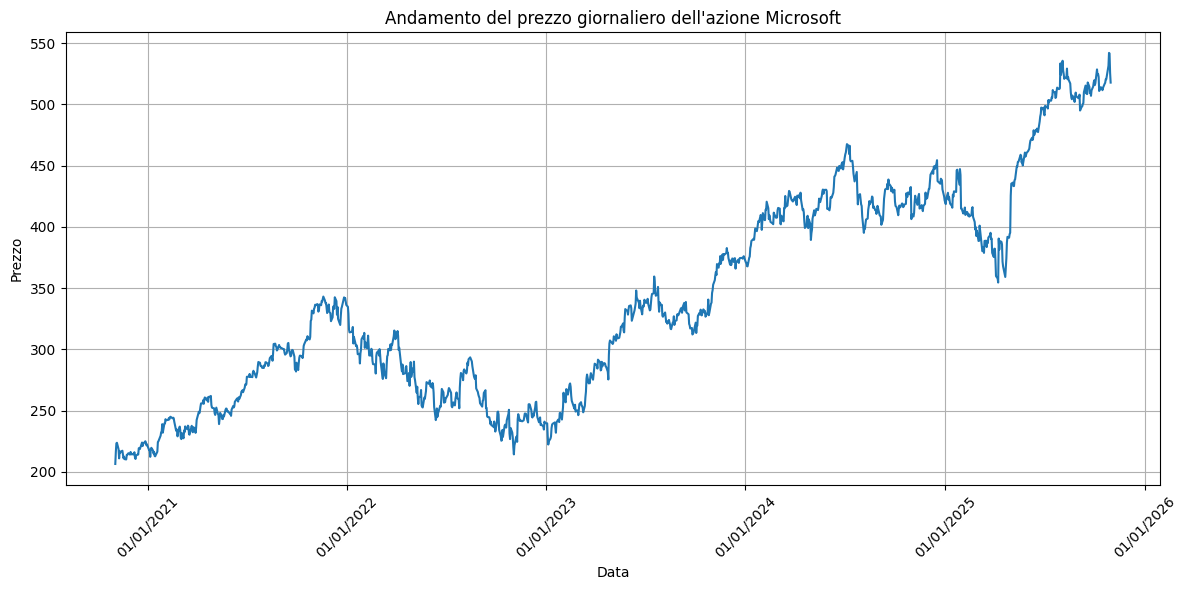

Nel periodo analizzato si osserva una fase di difficoltà nel biennio 2022-2023 causata dall'elevata inflazione, seguita da una forte ripresa trainata dallo sviluppo dell'intelligenza artificiale.
Questo comportamento potrebbe riflettere le caratteristiche tipiche del settore tecnologico in cui opera l'azienda.


In [ ]:
# Grafico del prezzo delle azioni Microsoft nel tempo
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Ultimo'])
plt.title("Andamento del prezzo giornaliero dell'azione Microsoft")
plt.xlabel("Data")
plt.ylabel("Prezzo")
plt.grid()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d/%m/%Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print("Nel periodo analizzato si osserva una fase di difficoltà nel biennio 2022-2023 causata dall'elevata inflazione, seguita da una forte ripresa trainata dallo sviluppo dell'intelligenza artificiale.")
print("Questo comportamento potrebbe riflettere le caratteristiche tipiche del settore tecnologico in cui opera l'azienda.")

In [ ]:
# Itera attraverso i periodi definiti e calcolo la media mobile
for window in MEDIA_MOBILE_WINDOWS:
    df[f'media_mobile_{window}_giorni'] = df['Ultimo'].rolling(window=window).mean()

In [ ]:
# Itera attraverso i periodi definiti e calcolo la volatilità
for window in VOLATILITÀ_WINDOWS:
    df[f'volatilità_{window}_giorni'] = df['Ultimo'].rolling(window=window).std() * np.sqrt(252)

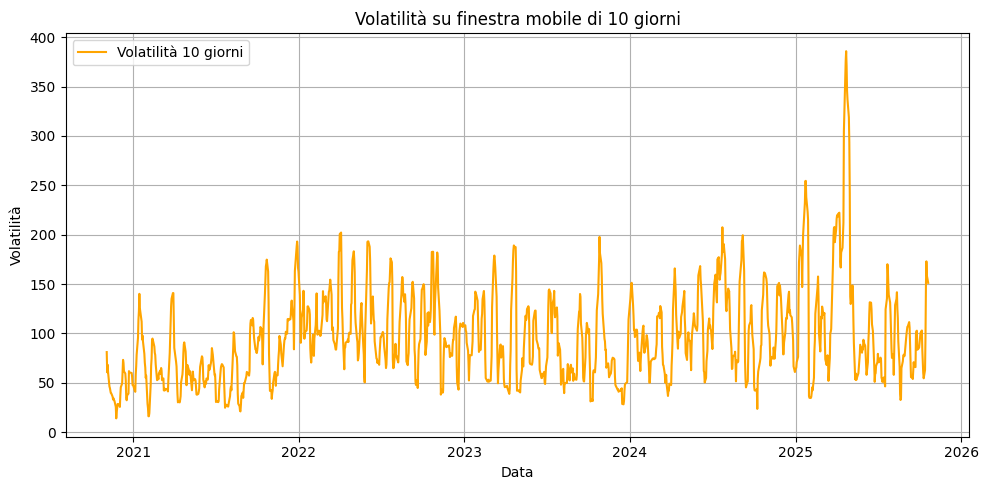

Osserviamo un aumento progressivo della volatilità nel tempo, con picchi particolarmente accentuati nel 2025.
Questo comportamento potrebbe indicare un incremento dell'incertezza nei mercati sopratutto nel settore tecnologico.


In [ ]:
# Grafico della volatilità su finestra mobile di 10 giorni
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['volatilità_10_giorni'], label='Volatilità 10 giorni', color='orange')
plt.title("Volatilità su finestra mobile di 10 giorni")
plt.xlabel("Data")
plt.ylabel("Volatilità")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
print("Osserviamo un aumento progressivo della volatilità nel tempo, con picchi particolarmente accentuati nel 2025.")
print("Questo comportamento potrebbe indicare un incremento dell'incertezza nei mercati sopratutto nel settore tecnologico.")

In [ ]:
# Creazione delle Lag Features sui rendimenti
def crea_lag_rendimenti(df, num_lag):
    for i in range(1, num_lag + 1):
        df[f'rendimento_lag_{i}'] = df['rendimento'].shift(i)
    return df

df = crea_lag_rendimenti(df, LAGS)

In [ ]:
# Creazione delle lag features sulla volatilità
def crea_lag_volatilità(df, num_lag, colonna_volatilità):
    for i in range(1, num_lag + 1):
        df[f'volatilità_lag_{i}'] = df[colonna_volatilità].shift(i)
    return df

# Definisco la colonna di volatilità da usare
colonna_volatilità = 'volatilità_10_giorni'

df = crea_lag_volatilità(df, LAGS, colonna_volatilità)

In [ ]:
# Definizione della Variabile Target
df['target'] = (df['Ultimo'].shift(-1) > df['Ultimo']).astype(int)

In [ ]:
#Elimino le righe con valori mancanti
df.dropna(inplace=True)

In [ ]:
# Controllo come sono le prime righe
print(df.head())

# Controllo se ci sono ancora NaN
print("\nValori mancanti:")
print(df.isnull().sum())

            Ultimo  Apertura  Massimo  Minimo  rendimento  \
Data                                                        
2025-10-06  528.57    518.61   531.03  518.20      0.0217   
2025-10-03  517.35    517.10   520.49  515.00      0.0031   
2025-10-02  515.74    517.64   521.60  510.68     -0.0076   
2025-10-01  519.71    514.80   520.51  511.69      0.0034   
2025-09-30  517.95    513.24   518.16  509.66      0.0065   

            media_mobile_5_giorni  media_mobile_10_giorni  \
Data                                                        
2025-10-06                522.152                 517.700   
2025-10-03                523.430                 518.077   
2025-10-02                522.098                 518.490   
2025-10-01                521.070                 519.118   
2025-09-30                519.864                 519.556   

            media_mobile_20_giorni  volatilità_5_giorni  volatilità_10_giorni  \
Data                                                           

In [ ]:
# Importo le librerie necessarie
from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Divisione in train e test con 70% e 30%
train_size = int(len(df) * TRAIN_SIZE)
train = df.iloc[:train_size]
test = df.iloc[train_size:]

# Definisco le feature SENZA 'rendimento' nel giorno odierno T
feature_cols = [
    'media_mobile_5_giorni', 'media_mobile_10_giorni', 'media_mobile_20_giorni',
    'volatilità_5_giorni', 'volatilità_10_giorni', 'volatilità_20_giorni',
    'rendimento_lag_1', 'rendimento_lag_2', 'rendimento_lag_3',
    'rendimento_lag_4', 'rendimento_lag_5',
    'volatilità_lag_1', 'volatilità_lag_2', 'volatilità_lag_3',
    'volatilità_lag_4', 'volatilità_lag_5'
]

# Separazione in X e y usando feature_cols
X_train = train[feature_cols]  # ✓ Cambia da .drop() a [feature_cols]
y_train = train['target']
X_test = test[feature_cols]    # ✓ Cambia da .drop() a [feature_cols]
y_test = test['target']

# Creo uno splitter con 5 divisioni
tscv = TimeSeriesSplit(n_splits=5)


In [ ]:
# Costruisco una pipeline: scaling + logistic regression
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(solver='liblinear', random_state=RANDOM_STATE))
])

# Validazione incrociata con TimeSeriesSplit
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=tscv, scoring='accuracy')

print("Accuracy per ciascun fold:")
print(cv_scores)
print(f"\nAccuracy media: {cv_scores.mean():.4f}")
print("NOTA: Il problema era che usando il rendimento (T) per predire il movimento di T+1 si  creava una dipendenza troppo forte.")
print("NOTA: Rimuovendo quindi T e usando solo i rendimento_lag_1 (rendimento di ieri = T-1).... fino a T-5")

Accuracy per ciascun fold:
[0.50694444 0.50694444 0.53472222 0.5        0.54861111]

Accuracy media: 0.5194
NOTA: Il problema era che usando il rendimento (T) per predire il movimento di T+1 si  creava una dipendenza troppo forte.
NOTA: Rimuovendo quindi T e usando solo i rendimento_lag_1 (rendimento di ieri = T-1).... fino a T-5


In [ ]:
# Alleno il modello finale
pipeline.fit(X_train, y_train)

# Previsioni sul test
y_pred = pipeline.predict(X_test)

# Risultati
print("Accuracy sul test set:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("Ricordando che la classe 0 indica una discesa di prezzo e la classe 1 una salita di prezzo possiamo vedere che:")
print("Il modello ha raggiunto un'accuratezza complessiva del 57% in linea con le aspettative.")
print("Per la classe 0 il modello indentifica correttamente il 59% delle previsioni (precision) e identifica correttamente il 54% dei casi reali (recall). Questo si traduce in un F1-score di 0.57.")
print("Per la classe 1 il modello mostra una precision del 55% e un ottimo recall del 60%, con un F1-score di 0.57.")
print("La matrice di confusione mostra che il modello ha prestazioni equilibrate su entrambe le classi, con una leggera tendenza a identificare meglio le salite di prezzo rispetto alle discese.")

Accuracy sul test set: 0.568733153638814

Classification Report:
               precision    recall  f1-score   support

           0       0.59      0.54      0.57       193
           1       0.55      0.60      0.57       178

    accuracy                           0.57       371
   macro avg       0.57      0.57      0.57       371
weighted avg       0.57      0.57      0.57       371


Confusion Matrix:
 [[104  89]
 [ 71 107]]
Ricordando che la classe 0 indica una discesa di prezzo e la classe 1 una salita di prezzo possiamo vedere che:
Il modello ha raggiunto un'accuratezza complessiva del 57% in linea con le aspettative.
Per la classe 0 il modello indentifica correttamente il 59% delle previsioni (precision) e identifica correttamente il 54% dei casi reali (recall). Questo si traduce in un F1-score di 0.57.
Per la classe 1 il modello mostra una precision del 55% e un ottimo recall del 60%, con un F1-score di 0.57.
La matrice di confusione mostra che il modello ha prestazioni equ

In [ ]:
# Prendiamo i dati più recenti (cioè la PRIMA riga del DataFrame ordinato decrescente)
latest_data = df[feature_cols].iloc[[0]]  # le doppie [[ ]] mantengono il DataFrame, non Series

# Previsione
predicted_class = pipeline.predict(latest_data)[0]

# Interpretazione del risultato
if predicted_class == 1:
    print("Il modello prevede che DOMANI il prezzo SALIRÀ.")
else:
    print("Il modello prevede che DOMANI il prezzo SCENDERÀ.")


Il modello prevede che DOMANI il prezzo SCENDERÀ.


In [ ]:
# Conta la distribuzione delle classi
print("Distribuzione del target (0 = non sale, 1 = sale):")
print(df['target'].value_counts(normalize=True) * 100)
print("Non c'è uno sbilanciamento delle classi")

Distribuzione del target (0 = non sale, 1 = sale):
target
0    52.427184
1    47.572816
Name: proportion, dtype: float64
Non c'è uno sbilanciamento delle classi


Percentuale giorni in aumento per anno:
Anno
2020    43.902439
2021    47.222222
2022    54.183267
2023    45.200000
2024    46.428571
2025    44.736842
Name: target, dtype: float64


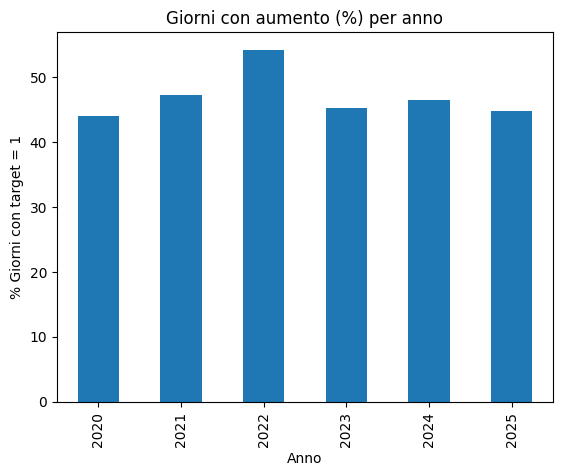

Notiamo che il 2022 è stato l'anno in cui ci sono stati più giorni di aumtento.
Può sembrare una contraddizione con l'andamento del prezzo dell'azione, ma è possibile che il 2022 abbia avuto pochi giorni con ribassi molto marcati
e allo stesso tempo un numero molto elevato di giorni con aumenti contenuti.


In [ ]:
# Aggiungi l'anno o mese
df['Anno'] = df.index.year
df['Mese'] = df.index.month

# Percentuale di target=1 per anno
target_by_year = df.groupby('Anno')['target'].mean() * 100
print("Percentuale giorni in aumento per anno:")
print(target_by_year)

# Plot se vuoi visualizzare
target_by_year.plot(kind='bar', title="Giorni con aumento (%) per anno")
plt.ylabel('% Giorni con target = 1')
plt.show()
print("Notiamo che il 2022 è stato l'anno in cui ci sono stati più giorni di aumtento.")
print("Può sembrare una contraddizione con l'andamento del prezzo dell'azione, ma è possibile che il 2022 abbia avuto pochi giorni con ribassi molto marcati")
print("e allo stesso tempo un numero molto elevato di giorni con aumenti contenuti.")

In [ ]:
# Numero di giorni con prezzo stabile
stable_days = (df['Ultimo'].diff().abs() < STABLE_PRICE_THRESHOLD).sum()
total_days = len(df)
print(f"Giorni con prezzo stabile: {stable_days} su {total_days} ({stable_days / total_days:.2%})")
print("Questo ci fa capire che il prezzo è sempre molto scambiato.")

Giorni con prezzo stabile: 1 su 1236 (0.08%)
Questo ci fa capire che il prezzo è sempre molto scambiato.
